In [2]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')
import pandas as pd

In [3]:
df = pd.read_csv('classifications.csv')
df

,zenodo_id,classification
0,4245576,NONE
1,4245412,source-separation
2,4245492,NONE
3,4245586,NONE
4,4245474,NONE
...,...,...
661,17811546,NONE
662,17811352,audio-beat-tracking
663,17811364,NONE
664,17811480,NONE


In [4]:
df['classification'].value_counts()

classification
NONE                            539
multi-f0-estimation              32
source-separation                31
audio-beat-tracking              18
audio-instrument-recognition     11
lyrics-transcription              9
cover-song-identification         8
audio-key-detection               7
audio-chord-estimation            6
audio-melody-extraction           5
Name: count, dtype: int64

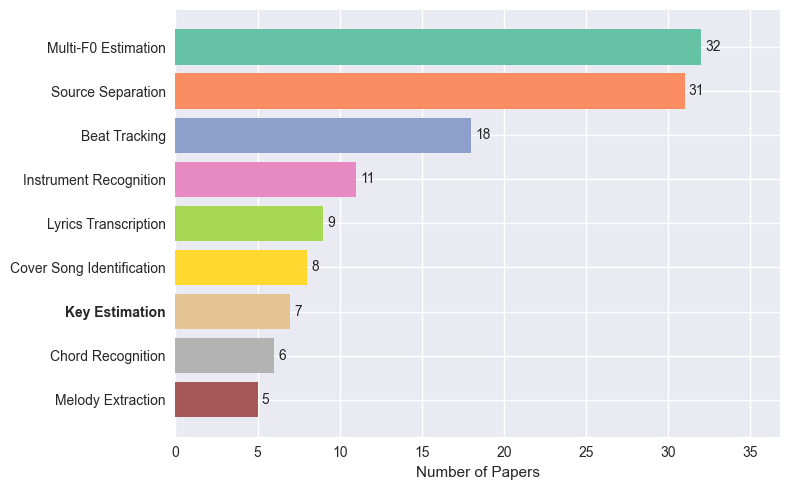

In [5]:
LABELS = {
    'multi-f0-estimation':          'Multi-F0 Estimation',
    'source-separation':            'Source Separation',
    'audio-beat-tracking':          'Beat Tracking',
    'audio-instrument-recognition': 'Instrument Recognition',
    'lyrics-transcription':         'Lyrics Transcription',
    'cover-song-identification':    'Cover Song Identification',
    'audio-key-detection':          'Key Estimation',
    'audio-chord-estimation':       'Chord Recognition',
    'audio-melody-extraction':      'Melody Extraction',
}

counts = df[df['classification'] != 'NONE']['classification'].value_counts()

labels = [LABELS[c] for c in counts.index]
colors = list(plt.cm.Set2.colors) + ['#a65858']  # extend past Set2's built-in 8

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(labels, counts.values, color=colors[:len(counts)])
ax.invert_yaxis()  # largest count on top

ax.bar_label(bars, padding=3)
ax.set_xlabel('Number of Papers')

for spine in ('top', 'right', 'left'):
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
ax.set_xlim(0, counts.max() * 1.15)

for tick_label in ax.get_yticklabels():
    if tick_label.get_text() == 'Key Estimation':
        tick_label.set_fontweight('bold')

plt.tight_layout()
plt.savefig('../writeup/figs/ismir-paper-counts.svg', format='svg', bbox_inches='tight', facecolor='none')
plt.show()
